In [141]:
# importing the packages
import numpy as np
import pandas as pd
from itertools import chain
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

In [142]:
# read the pairings.txt file
# Open the file in read mode
with open("../data/subset_pairings/subset_pairings.txt", "r") as file:
    lines = file.readlines()

# convert each line (representing a list) to an actual list
pairings = [eval(line) for line in lines]

# sort pairings based on the first element of each list
pairings.sort(key=lambda x: x[0])

In [143]:
# read the flight leg data
np_arr = pd.read_csv(
    "../data/flight_legs/data.csv",
    parse_dates=["start_time", "end_time"],
).to_numpy()

departure_time = [[np_arr[j][3] for j in i] for i in pairings]
flight_leg_id = [[np_arr[j][0] for j in i] for i in pairings]
departure_airport = [[np_arr[j][1] for j in i] for i in pairings]
destination_airport = [[np_arr[j][2] for j in i] for i in pairings]

In [144]:
flight_leg_id

[[1, 2, 39, 40],
 [9, 22, 43, 44],
 [13, 14, 47, 48],
 [17, 18, 51, 20],
 [21, 42, 11, 12],
 [25, 58, 59, 60],
 [29, 30, 37, 38],
 [31, 64, 35, 36],
 [33, 34, 3, 4],
 [41, 10, 7, 8],
 [45, 46, 15, 16],
 [49, 50, 19, 52],
 [53, 54, 55, 56],
 [57, 26, 27, 28],
 [61, 62, 5, 6],
 [63, 32, 23, 24]]

In [145]:
# convert to a dictionary where key is the 'sub_pair' & index +1
pairings_dict = {f"P{i+1}": pair for i, pair in enumerate(departure_time)}

In [146]:
pairings_dict

{'P1': [Timestamp('2023-01-01 17:00:00'),
  Timestamp('2023-01-01 19:00:00'),
  Timestamp('2023-01-02 08:00:00'),
  Timestamp('2023-01-02 10:00:00')],
 'P2': [Timestamp('2023-01-01 19:00:00'),
  Timestamp('2023-01-01 21:00:00'),
  Timestamp('2023-01-02 11:00:00'),
  Timestamp('2023-01-02 13:00:00')],
 'P3': [Timestamp('2023-01-01 13:00:00'),
  Timestamp('2023-01-01 15:00:00'),
  Timestamp('2023-01-02 06:00:00'),
  Timestamp('2023-01-02 08:00:00')],
 'P4': [Timestamp('2023-01-01 12:00:00'),
  Timestamp('2023-01-01 14:00:00'),
  Timestamp('2023-01-02 05:00:00'),
  Timestamp('2023-01-02 07:00:00')],
 'P5': [Timestamp('2023-01-01 19:00:00'),
  Timestamp('2023-01-01 21:00:00'),
  Timestamp('2023-01-02 11:00:00'),
  Timestamp('2023-01-02 13:00:00')],
 'P6': [Timestamp('2023-01-02 01:00:00'),
  Timestamp('2023-01-02 03:00:00'),
  Timestamp('2023-01-02 17:00:00'),
  Timestamp('2023-01-02 19:00:00')],
 'P7': [Timestamp('2023-01-01 01:00:00'),
  Timestamp('2023-01-01 03:00:00'),
  Timestamp('202

In [ ]:
# add 10 mins to a timestamp


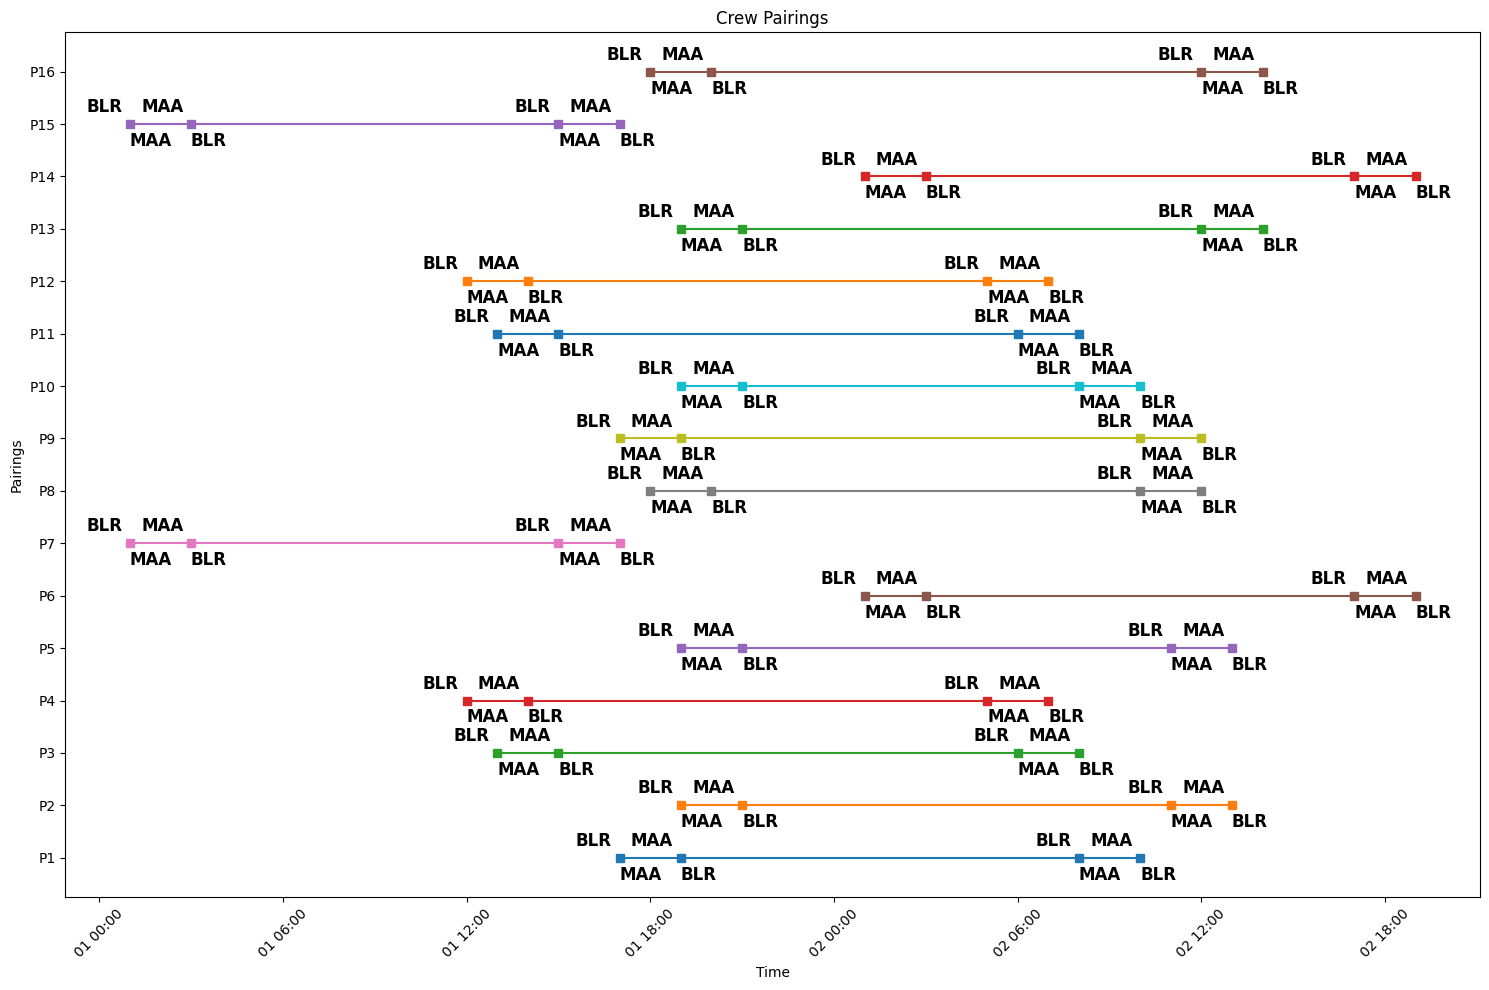

In [171]:
# Plotting
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot()

# Iterate over dictionary items and plot
for i, (key, value) in enumerate(pairings_dict.items()):
    ax.plot(value, [i] * len(value), marker="s", label=key)
    for j, (x, y) in enumerate(zip(value, [i] * len(value))):
        # ax.text(
        #     val,
        #     i,
        #     flight_leg_id[i][j],
        #     fontsize=10,
        #     verticalalignment="bottom",
        #     horizontalalignment="center",
        #     fontweight="bold",
        # )
        #ax.annotate(f'{flight_leg_id[i][j]}', xy=(x, y), xytext=(x + pd.Timedelta(minutes=15), y + 0.15), textcoords='data', ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax.annotate(f'{departure_airport[i][j]}', xy=(x, y), xytext=(x - pd.Timedelta(minutes=15), y + 0.15), textcoords='data', ha='right', va='bottom', fontsize=12, fontweight='bold')
        ax.annotate(f'{destination_airport[i][j]}', xy=(x, y), xytext=(x, y - 0.15), textcoords='data', ha='left', va='top', fontsize=12, fontweight='bold')

# Set y-axis ticks and labels
ax.set_yticks(range(len(pairings_dict)))
ax.set_yticklabels(pairings_dict.keys())

# Set x-axis date format
date_format = DateFormatter("%d %H:%M")
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

# Set labels and title
plt.xlabel("Time")
plt.ylabel("Pairings")
plt.title("Crew Pairings")

# Show plot
plt.tight_layout()
plt.show()